In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/tabela_base_traduzida.csv')

# Análise exploratória (EDA)

---

#### Este arquivo é responsável pela análise explorátoria (EDA) dos dados tratados, é por meio dele que irkemos conhecer os dados que estamos trabalhando e quais análises poderemos realizar

## Perguntas e variáveis análisadas

- Taxa global de atrito: Quantas pessoas saíram vs quantas continuam na empresa
- Taxa de atrito por gênero
- Áreas com maiores perdas de funcionários
- Cargos com mais pedidos de demissão
- Funcionários com menos tempo de casa saem mais ? Isso afeta diretamente o cargo ?
- Pedidos de demissão vs Salário e benefícios
- Razão salarial | salário do funcionário / média do cargo
- Carga de hora trabalhada | Quem costuma fazer hora extra costuma sair mais ?
- Equilíbrio de vida vs Pedidos de demissão
- Engajamento vs Pedidos de demissão
- Distância do trabalho vs pedidos de demissão
- Viagens a negócio interferem nos pedidos de demissão ?

---

> Taxa global de atrito: Quantas pessoas saíram vs quantas continuam na empresa

In [11]:
ativos = df.groupby(df["Demitido"] == "No").size()
demitidos = df.groupby(df["Demitido"] == "Yes").size()

p_ativos = ativos[True] / (ativos[True] + demitidos[True]) * 100
p_demitidos = demitidos[True] / (ativos[True] + demitidos[True]) * 100

print(f"A empresa possui {p_ativos:.2f}% de funcionários ativos e {p_demitidos:.2f}% de funcionários demitidos. Os valores absolutos são {ativos[True]} funcionários ativos e {demitidos[True]} funcionários demitidos.")

A empresa possui 83.88% de funcionários ativos e 16.12% de funcionários demitidos. Os valores absolutos são 1233 funcionários ativos e 237 funcionários demitidos.


> Taxa de atrito por gênero

Dentre os demitidos, que representam 16.12% do total de registros, 10.20% são do gênero masculino e 5.92% são do gênero feminino. Os valores absolutos são 150 demitidos do gênero masculino e 87 demitidos do gênero feminino.


Text(0, 0.5, 'Número de Funcionários')

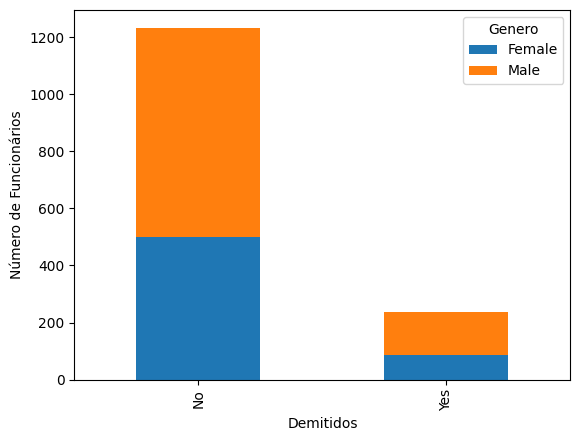

In [28]:
demitidos_genero = df.groupby(["Demitido", "Genero"]).size()

linhas_masculinas = len(df["Genero"] == "Male")
linhas_femininas = len(df["Genero"] == "Female")

demitidos_masculino = demitidos_genero[("Yes", "Male")]
demitidos_feminino = demitidos_genero[("Yes", "Female")]

numero_linhas = len(df)

p_masculino = demitidos_masculino / linhas_masculinas * 100
p_feminino = demitidos_feminino / linhas_femininas * 100

soma_p = p_masculino + p_feminino

print(f"Dentre os demitidos, que representam {soma_p:.2f}% do total de registros, {p_masculino:.2f}% são do gênero masculino e {p_feminino:.2f}% são do gênero feminino. Os valores absolutos são {demitidos_masculino} demitidos do gênero masculino e {demitidos_feminino} demitidos do gênero feminino.")

demitidos_genero.unstack().plot(kind="bar", stacked=True, ax=plt.gca())
plt.xlabel("Demitidos")
plt.ylabel("Número de Funcionários")

> Áreas com maiores perdas de funcionários

Departamento
Sales                     6959.17
Human Resources           6654.51
Research & Development    6281.25
Name: Renda_Mensal, dtype: float64

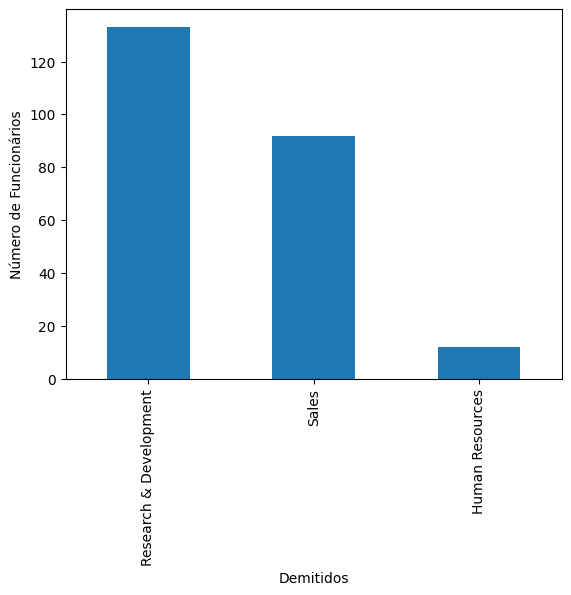

In [61]:
perda_departamento = df.groupby([df["Demitido"] == "Yes", "Departamento"]).size()
media_salarios_departamento = df.groupby("Departamento")["Renda_Mensal"].mean()


perda_departamento[True].sort_values(ascending = False).plot(kind="bar", stacked=True, ax=plt.gca())
plt.xlabel("Demitidos")
plt.ylabel("Número de Funcionários")

media_salarios_departamento.round(2).sort_values(ascending = False)

> Cargos com mais pedidos de demissão

Cargo
Manager                      17181.68
Research Director            16033.55
Healthcare Representative     7528.76
Manufacturing Director        7295.14
Sales Executive               6924.28
Human Resources               4235.75
Research Scientist            3239.97
Laboratory Technician         3237.17
Sales Representative          2626.00
Name: Renda_Mensal, dtype: float64

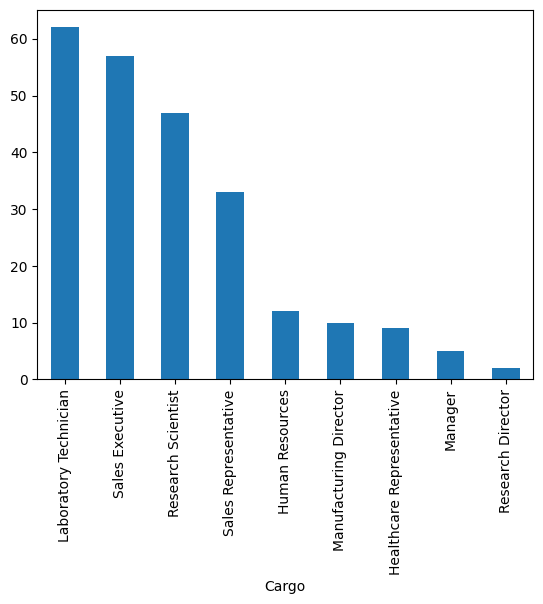

In [62]:
media_salarios_cargo = df.groupby("Cargo")["Renda_Mensal"].mean().sort_values(ascending=False).round(2)
demitidos_cargo = df[df["Demitido"] == "Yes"].groupby("Cargo").size()

demitidos_cargo.sort_values(ascending = False).plot(kind="bar", label="Demitidos")
media_salarios_cargo

> Funcionários com menos tempo de casa saem mais ? Isso afeta diretamente o cargo ?

---

> arrumar código a partir daqui

Cargo
Laboratory Technician        62
Sales Executive              57
Research Scientist           47
Sales Representative         33
Human Resources              12
Manufacturing Director       10
Healthcare Representative     9
Manager                       5
Research Director             2
dtype: int64


C:\Users\Igor Cruz\AppData\Local\Temp\ipykernel_40644\1489114691.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demitidos_cargo = df[df["Demitido"] == "Yes"].groupby("Cargo").size()


<Axes: xlabel='Cargo'>

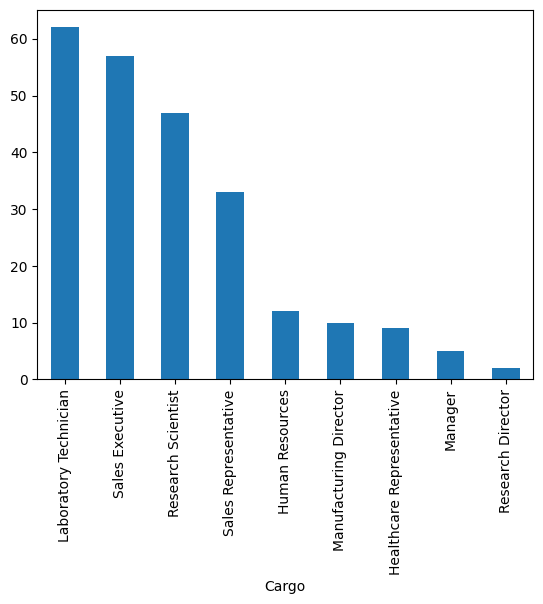

In [48]:
demitidos_cargo = df[df["Demitido"] == "Yes"].groupby("Cargo").size()

print(demitidos_cargo.sort_values(ascending=False).head(10))
demitidos_cargo.sort_values(ascending=False).head(10).plot(kind="bar")

Estado_Civil
Single      120
Married      84
Divorced     33
dtype: int64


C:\Users\Igor Cruz\AppData\Local\Temp\ipykernel_40644\2588484266.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demitidos_estado_civil = df[df["Demitido"] == "Yes"].groupby("Estado_Civil").size()


<Axes: xlabel='Estado_Civil'>

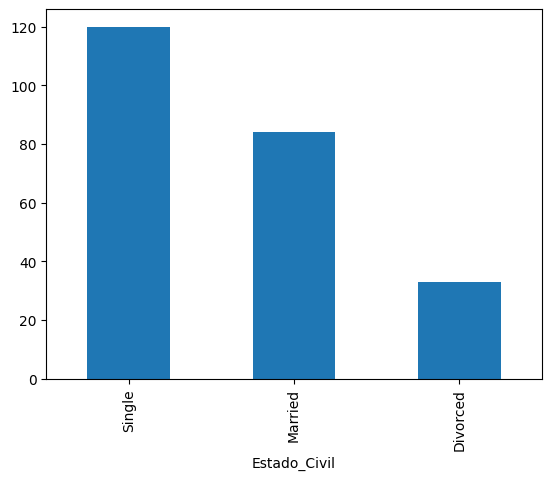

In [49]:
demitidos_estado_civil = df[df["Demitido"] == "Yes"].groupby("Estado_Civil").size()

print(demitidos_estado_civil.sort_values(ascending=False).head(10))
demitidos_estado_civil.sort_values(ascending=False).head(10).plot(kind="bar")

In [ ]:
for i in df.columns:
    print(f"{i}")  

Idade
Demitido
Viagens_a_Negocio
Valor_Diaria
Departamento
Distancia_de_Casa
Escolaridade
Area_de_Formacao
Contagem_de_Funcionarios
ID_Funcionario
Satisfacao_com_Ambiente
Genero
Valor_Hora
Envolvimento_com_Trabalho
Nivel_do_Cargo
Cargo
Satisfacao_com_Trabalho
Estado_Civil
Renda_Mensal
Valor_Mensal
Numero_de_Empresas_Anteriores
Maior_de_18
Hora_Extra
Percentual_Aumento_Salario
Avaliacao_Desempenho
Satisfacao_Relacionamento
Horas_Padrao
StockOptionLevel
Total_Anos_Trabalhados
Treinamentos_Ano_Passado
Equilibrio_Vida_Trabalho
Anos_na_Empresa
Anos_no_Cargo_Atual
Anos_Desde_Ultima_Promocao
Anos_com_Gerente_Atual


In [61]:
demitidos = df[df["Demitido"] == "Yes"]["Idade"]
ativos = df[df["Demitido"] == "No"]["Idade"]

print(f"Idade média demitidos: {demitidos.mean().round(2)}\nIdade média ativos: {ativos.mean().round(2)}")

Idade média demitidos: 33.61
Idade média ativos: 37.56


In [64]:
df["Faixa_Etaria"] = df["Idade"].apply(
    lambda x: "Jovem" if 18 <= x <= 29
    else "Adulto" if 30 <= x <= 44
    else "Maduro" if 45 <= x <= 59
    else "Idoso"
)

# mandante['pontos'] = mandante.apply(
#    # Calculando ponntuação
#    lambda x: 3 if x['gols_pro'] > x['gols_contra']
#    else 1 if x['gols_pro'] == x['gols_contra']
#    else 0,
#    axis=1

# | Faixa Etária    | Classificação |
# | --------------- | ------------- |
# | 18 a 29 anos    | Jovem         |
# | 30 a 44 anos    | Adulto        |
# | 45 a 59 anos    | Maduro        |
# | 60 anos ou mais | Idoso         |


<Axes: xlabel='Faixa_Etaria'>

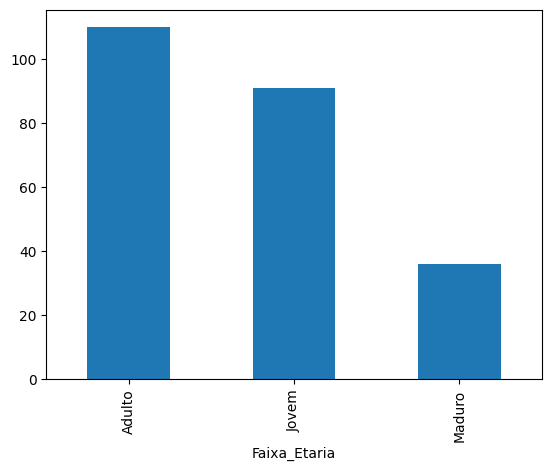

In [25]:
demitidos_faixa_etaria = df[df["Demitido"] == "Yes"].groupby("Faixa_Etaria").size()
demitidos_faixa_etaria.sort_values(ascending = False).plot(kind = "bar")

C:\Users\Igor Cruz\AppData\Local\Temp\ipykernel_40644\402930939.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_salarios_cargo = df.groupby("Cargo")["Renda_Mensal"].mean().sort_values(ascending=False).round(2)
C:\Users\Igor Cruz\AppData\Local\Temp\ipykernel_40644\402930939.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demitidos_cargo = df[df["Demitido"] == "Yes"].groupby("Cargo").size()


Cargo
Manager                      17181.68
Research Director            16033.55
Healthcare Representative     7528.76
Manufacturing Director        7295.14
Sales Executive               6924.28
Human Resources               4235.75
Research Scientist            3239.97
Laboratory Technician         3237.17
Sales Representative          2626.00
Name: Renda_Mensal, dtype: float64

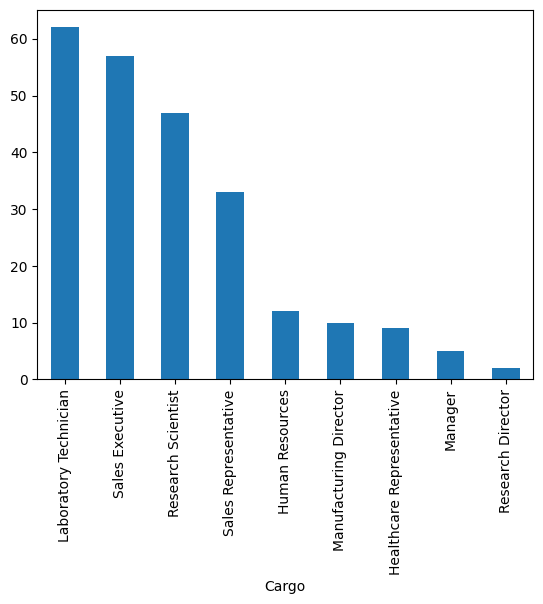

In [9]:
import csv

df.to_csv('../data/tabela_base_traduzida.csv', index=False, quoting=csv.QUOTE_ALL)

In [20]:
total_f = df.groupby(df["Genero"] == "Female").size()
total_m = df.groupby(df["Genero"] == "Male").size()

ativos_f = df[df["Demitido"] == "No"].groupby(df["Genero"] == "Female").size()
ativos_m = df[df["Demitido"] == "No"].groupby(df["Genero"] == "Male").size()

demitidos_f = df[df["Demitido"] == "Yes"].groupby(df["Genero"] == "Female").size()
demitidos_m = df[df["Demitido"] == "Yes"].groupby(df["Genero"] == "Male").size()

porcentagem_demitidos_f = (demitidos_f[True] / total_f[True]) * 100
porcentagem_demitidos_m = (demitidos_m[True] / total_m[True]) * 100


print(f"Total de mulheres: {total_f[True]} | Ativas: {ativos_f[True]} | Demitidas: {demitidos_f[True]} | Porcentagem de demissão: {porcentagem_demitidos_f:.2f}%")
print(f"Total de homens: {total_m[True]} | Ativos: {ativos_m[True]} | Demitidos: {demitidos_m[True]} | Porcentagem de demissão: {porcentagem_demitidos_m:.2f}%")





Total de mulheres: 588 | Ativas: 501 | Demitidas: 87 | Porcentagem de demissão: 14.80%
Total de homens: 882 | Ativos: 732 | Demitidos: 150 | Porcentagem de demissão: 17.01%


In [23]:
tecnico_labolatorio_demitidos_genero = df[(df["Demitido"] == "Yes") & (df["Cargo"] == "Laboratory Technician")].groupby("Genero").size()
tecnico_labolatorio_demitidos_genero

Genero
Female    16
Male      46
dtype: int64

In [38]:
total_demitidos = df.groupby(df["Demitido"] == "Yes").size()

demitidos_jovem = df[df["Demitido"] == "Yes"].groupby(df["Faixa_Etaria"] == "Jovem").size()
demitidos_adulto = df[df["Demitido"] == "Yes"].groupby(df["Faixa_Etaria"] == "Adulto").size()
demitidos_maduro = df[df["Demitido"] == "Yes"].groupby(df["Faixa_Etaria"] == "Maduro").size()

faixa_etaria_base = df.groupby("Faixa_Etaria").size()

porcentagem_demitidos_jovem = (demitidos_jovem[True] / total_demitidos[True]) * 100
porcentagem_demitidos_adulto = (demitidos_adulto[True] / total_demitidos[True]) * 100
porcentagem_demitidos_maduro = (demitidos_maduro[True] / total_demitidos[True]) * 100

print(f"Total de demitidos: {total_demitidos[True]} \n Representação de jovens: {porcentagem_demitidos_jovem:.2f}% \n Representação de adultos: {porcentagem_demitidos_adulto:.2f}% \n Representação de maduros: {porcentagem_demitidos_maduro:.2f}%")



Total de demitidos: 237 
 Representação de jovens: 38.40% 
 Representação de adultos: 46.41% 
 Representação de maduros: 15.19%


In [63]:
soma_salarios = df["Renda_Mensal"].sum().round(2)
soma_salarios

salario_tecnico_laboratorio = df[df["Cargo"] == "Laboratory Technician"]["Renda_Mensal"].sum().round(2)
salario_maneger = df[df["Cargo"] == "Manager"]["Renda_Mensal"].sum().round(2)
salario_diretor = df[df["Cargo"] == "Research Director"]["Renda_Mensal"].sum().round(2)

representacao_tecnico_laboratorio = (salario_tecnico_laboratorio / soma_salarios) * 100

cargos = df[df["Cargo"].isin(["Laboratory Technician", "Manager", "Research Director"])].groupby("Cargo").size()


print(f"Técnicos de laboratório {representacao_tecnico_laboratorio:.2f}% \n Manager {salario_maneger / soma_salarios * 100:.2f}% \n Diretor {salario_diretor / soma_salarios * 100:.2f}% \n\n {cargos}" )

Técnicos de laboratório 8.77% 
 Manager 18.33% 
 Diretor 13.42% 

 Cargo
Laboratory Technician    259
Manager                  102
Research Director         80
dtype: int64


Após realizar a análise exploratória, segue minhas anotações de alguns dados percebidos:

---

Variáveis analisadas até o instante:

01. Demitidos por Gênero
02. Demitidos por Faxetária de Idade
03. Demitidos por Cargo

---

01. Demitidos por Gênero:

A maior taxa de demissão por gênero é masculina, a análise apresenta que 17,01% dos homens foram demitidos, enquanto para mulheres, as demissões representam 17,8%

02. Demitidos por faxetaria de idade:

A maior parte dos demitidos são adultos 46,41% (30 - 44 anos), seguidos por jovens 38,40% (18 - 29 anos), e por último, maduros 15,19% (45-59 anos)

03. Demitidos por cargo: 

A maior quantidade de cargos demitidos são os técnicos de laborátório que, mesmo representando o maior número de cargos (259) só representa 8% do total gasto pela empresa em salários
Em contra partida, os que menos possuem demissões são os Diretores de Pesquisas (80) e os Técnicos (102), que por suas vezes, representam 13,42% e 18,43% do mesmo total gasto em salário 


